# Churn modeling — baseline

Stratified train/test split, preprocessing (`StandardScaler` on numerics, `OneHotEncoder` on `plan_type`), and two baselines: **logistic regression** and **random forest**.

Metrics emphasize **ROC-AUC** and **PR-AUC** (imbalanced ~57% churn).


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

REPO = Path.cwd().resolve()
if not (REPO / "src" / "churn_data.py").is_file():
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from src.churn_data import CATEGORICAL_FEATURES, NUMERIC_FEATURES, load_raw_csv, prepare_features_and_target

%matplotlib inline


In [2]:
df = load_raw_csv()
X, y = prepare_features_and_target(df)
X.shape, y.shape, y.mean().round(3)


((2800, 7), (2800,), np.float64(0.573))

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)
X_train.shape, X_test.shape, y_train.mean().round(3), y_test.mean().round(3)


((2100, 7), (700, 7), np.float64(0.573), np.float64(0.573))

### Preprocessing + models

Numeric columns are scaled; `plan_type` is one-hot encoded with unknown categories ignored.


In [4]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            CATEGORICAL_FEATURES,
        ),
    ]
)

pipe_lr = Pipeline(
    steps=[
        ("prep", preprocessor),
        (
            "clf",
            LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs"),
        ),
    ]
)

pipe_rf = Pipeline(
    steps=[
        ("prep", preprocessor),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=12,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1,
            ),
        ),
    ]
)


In [5]:
pipe_lr.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)
"fitted"


'fitted'

### Metrics (test set)


=== Logistic regression ===
ROC-AUC: 0.7003
PR-AUC : 0.7258
              precision    recall  f1-score   support

           0      0.573     0.672     0.618       299
           1      0.719     0.626     0.669       401

    accuracy                          0.646       700
   macro avg      0.646     0.649     0.644       700
weighted avg      0.657     0.646     0.648       700



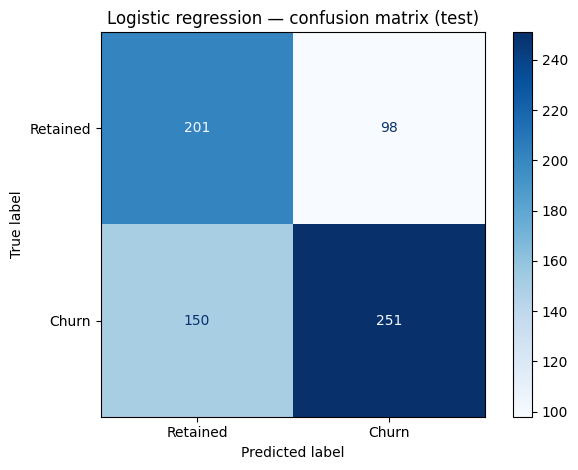

=== Random forest ===
ROC-AUC: 0.7056
PR-AUC : 0.7625
              precision    recall  f1-score   support

           0      0.587     0.542     0.563       299
           1      0.677     0.716     0.696       401

    accuracy                          0.641       700
   macro avg      0.632     0.629     0.630       700
weighted avg      0.638     0.641     0.639       700



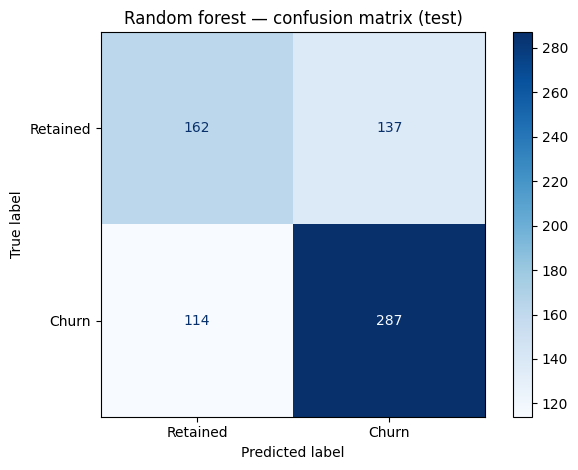

In [6]:
def report(name, model):
    proba = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    roc = roc_auc_score(y_test, proba)
    pr = average_precision_score(y_test, proba)
    print(f"=== {name} ===")
    print(f"ROC-AUC: {roc:.4f}")
    print(f"PR-AUC : {pr:.4f}")
    print(classification_report(y_test, pred, digits=3))
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Retained", "Churn"])
    disp.plot(cmap="Blues")
    plt.title(f"{name} — confusion matrix (test)")
    plt.tight_layout()
    plt.show()


report("Logistic regression", pipe_lr)
report("Random forest", pipe_rf)


## Results summary & interpretation

Quantitative recap on the **held-out test set**, plus what the models suggest about churn drivers.


In [7]:
# --- Test-set metrics (compact) ---
from sklearn.metrics import roc_auc_score, average_precision_score

rows = []
for name, model in [("Logistic regression", pipe_lr), ("Random forest", pipe_rf)]:
    proba = model.predict_proba(X_test)[:, 1]
    rows.append(
        {
            "model": name,
            "roc_auc": roc_auc_score(y_test, proba),
            "pr_auc": average_precision_score(y_test, proba),
        }
    )

metrics_df = pd.DataFrame(rows).set_index("model")
display(metrics_df.round(4))

# --- Random Forest: global feature importance (post one-hot + scaling block) ---
prep_rf = pipe_rf.named_steps["prep"]
feat_names = prep_rf.get_feature_names_out()
imps = pipe_rf.named_steps["clf"].feature_importances_
imp_df = (
    pd.DataFrame({"feature": feat_names, "importance": imps})
    .sort_values("importance", ascending=False)
    .head(12)
    .reset_index(drop=True)
)
print("\nTop Random Forest importances (higher = more split gain in the forest):")
display(imp_df)

# --- Logistic regression: largest standardized coefficients ---
prep_lr = pipe_lr.named_steps["prep"]
fn_lr = prep_lr.get_feature_names_out()
coef = pipe_lr.named_steps["clf"].coef_.ravel()
coef_df = pd.DataFrame({"feature": fn_lr, "coef": coef}).assign(abs_coef=lambda d: d["coef"].abs())
print("\nLogistic regression — largest |coefficient| (direction: + pushes toward churn=1):")
display(coef_df.sort_values("abs_coef", ascending=False).drop(columns="abs_coef").head(15).reset_index(drop=True))

# --- Short interpretation (narrative) ---
base_rate = float(y_test.mean())
best_roc = metrics_df["roc_auc"].idxmax()
best_pr = metrics_df["pr_auc"].idxmax()
print("\n--- Interpretation (plain language) ---")
print(
    f"• Test-set churn prevalence is {base_rate:.1%}. PR-AUC should be read against that baseline "
    f"(a model with PR-AUC near the prevalence is not much better than 'always predict churn')."
)
print(f"• Best ROC-AUC on this split: **{best_roc}** ({metrics_df.loc[best_roc, 'roc_auc']:.4f}).")
print(f"• Best PR-AUC on this split: **{best_pr}** ({metrics_df.loc[best_pr, 'pr_auc']:.4f}).")
print(
    "• Random Forest importances rank which transformed inputs the trees used most often for splits; "
    "they are not causal effects but align with 'where the signal lived' for this dataset."
)
print(
    "• Logistic coefficients are on the **scaled numeric** features and **one-hot plan** columns: "
    "a positive sign increases the log-odds of churn holding the rest fixed (linear model assumption)."
)
top3 = imp_df.head(3)["feature"].tolist()
print(f"• RF top-3 drivers by importance here: {', '.join(top3)}.")


,roc_auc,pr_auc
model,,
Logistic regression,0.7003,0.7258
Random forest,0.7056,0.7625



Top Random Forest importances (higher = more split gain in the forest):


,feature,importance
0,num__avg_weekly_usage_hours,0.268520
1,num__last_login_days_ago,0.228581
2,num__tenure_months,0.180630
3,num__payment_failures,0.138729
4,num__support_tickets,0.123478
5,num__monthly_fee,0.021935
6,cat__plan_type_Standard,0.013995
7,cat__plan_type_Basic,0.012127
8,cat__plan_type_Premium,0.012006



Logistic regression — largest |coefficient| (direction: + pushes toward churn=1):


,feature,coef
0,num__payment_failures,0.503280
1,num__last_login_days_ago,0.402393
2,num__support_tickets,0.367025
3,num__avg_weekly_usage_hours,-0.263631
4,cat__plan_type_Premium,0.017642
5,cat__plan_type_Basic,0.014954
6,num__tenure_months,-0.007916
7,num__monthly_fee,0.006117
8,cat__plan_type_Standard,-0.003572



--- Interpretation (plain language) ---
• Test-set churn prevalence is 57.3%. PR-AUC should be read against that baseline (a model with PR-AUC near the prevalence is not much better than 'always predict churn').
• Best ROC-AUC on this split: **Random forest** (0.7056).
• Best PR-AUC on this split: **Random forest** (0.7625).
• Random Forest importances rank which transformed inputs the trees used most often for splits; they are not causal effects but align with 'where the signal lived' for this dataset.
• Logistic coefficients are on the **scaled numeric** features and **one-hot plan** columns: a positive sign increases the log-odds of churn holding the rest fixed (linear model assumption).
• RF top-3 drivers by importance here: num__avg_weekly_usage_hours, num__last_login_days_ago, num__tenure_months.


### Notes

- `class_weight="balanced"` helps with the ~57% churn prevalence but does not replace PR-AUC / business cost thinking.
- For production, align feature timestamps with the churn definition to avoid **temporal leakage** (see EDA notebook).
- Next steps: calibration, threshold tuning, or `HistGradientBoostingClassifier` for a stronger tabular baseline.
